In [5]:
import subprocess
subprocess.run(["pip", "install", "seaborn"], check=True)

CompletedProcess(args=['pip', 'install', 'seaborn'], returncode=0)

Loading data...
  Rows       : 234
  Columns    : 124
  Date range : 2005-01-01 to 2024-06-01
  GDP obs    : 77 quarterly observations

Running rolling-origin evaluation...
  Train start     : 2005-01-01
  Test window     : 2020-03-01 to 2024-06-01
  Vintages        : [-2, -1, 0]
  Lag depth       : 4 monthly lags per predictor
  Alpha grid      : 40 candidates in [1e-6, 1e6]
  Alpha selection : fixed holdout (8 quarters)
  OLS baseline    : LinearRegression (SVD/pseudoinverse under p>n)

  [2020-03-01]  alpha=1.43e+04  n_train=59  features=610  grid_min=ok  grid_max=ok
  [2020-06-01]  alpha=2.03e+02  n_train=60  features=610  grid_min=ok  grid_max=ok
  [2020-09-01]  alpha=1.00e-06  n_train=61  features=610  grid_min=HIT_MIN  grid_max=ok
  [2020-12-01]  alpha=1.00e-06  n_train=62  features=610  grid_min=HIT_MIN  grid_max=ok
  [2021-03-01]  alpha=1.00e-06  n_train=63  features=610  grid_min=HIT_MIN  grid_max=ok
  [2021-06-01]  alpha=1.00e-06  n_train=64  features=610  grid_min=HIT_MIN  

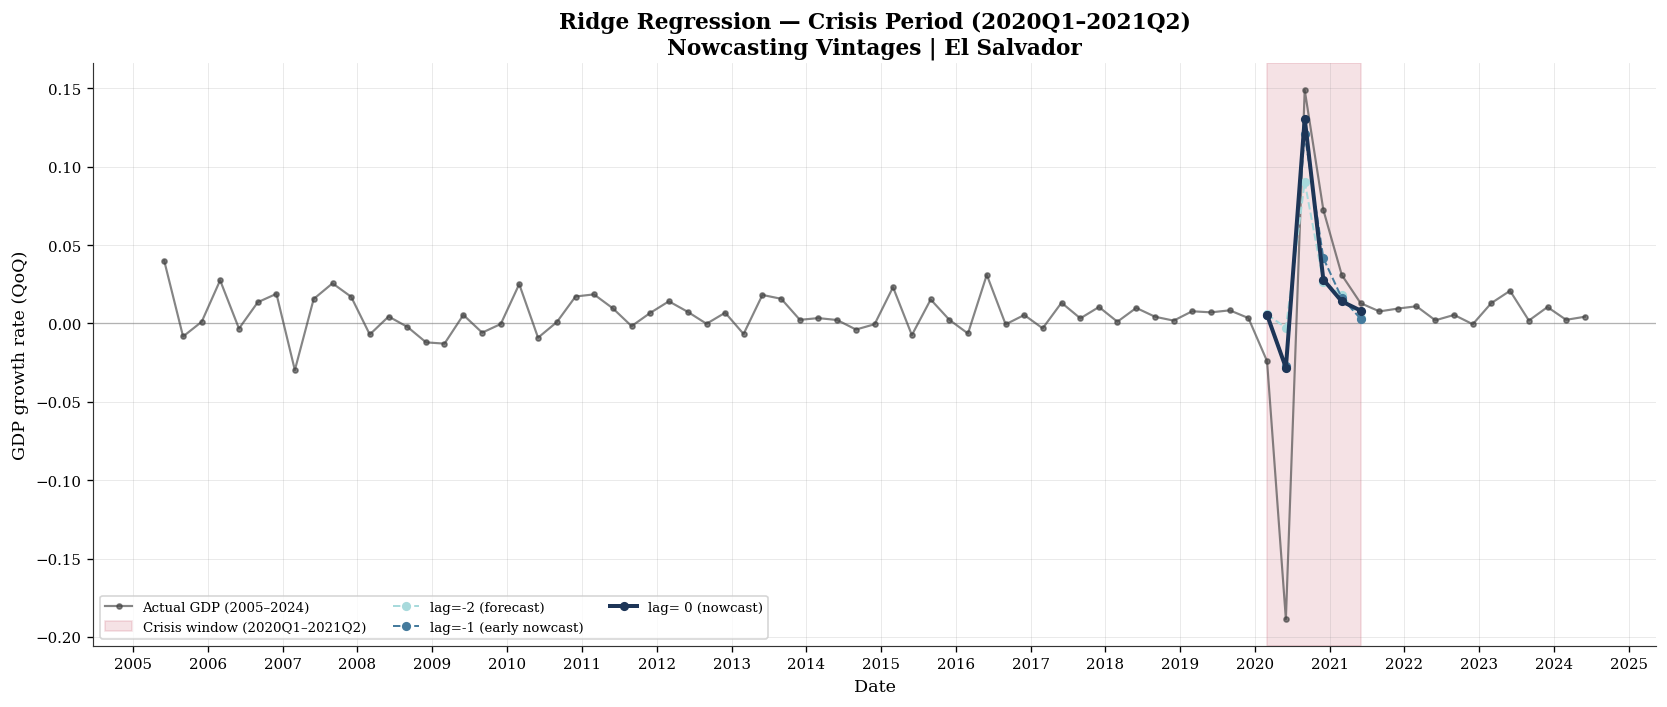

Saved: ridge_plot_crisis.png


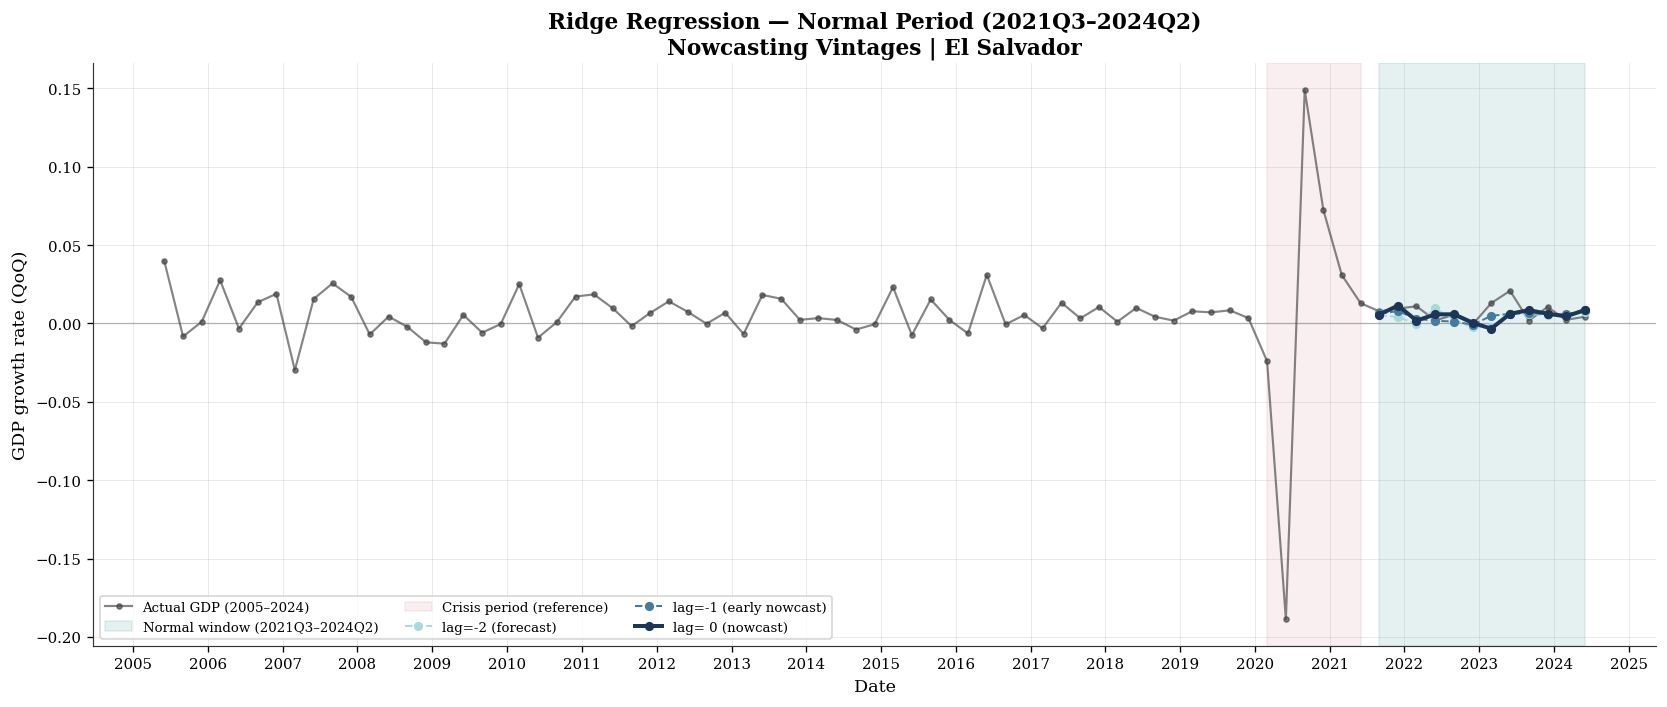

Saved: ridge_plot_normal.png


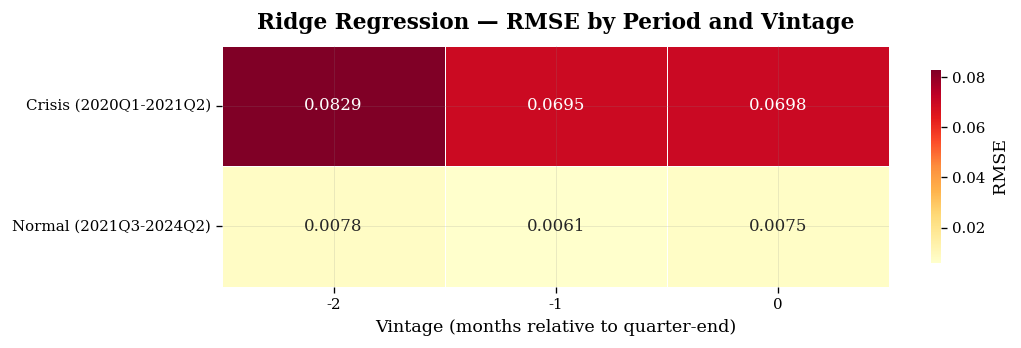

Saved: ridge_plot_heatmap.png


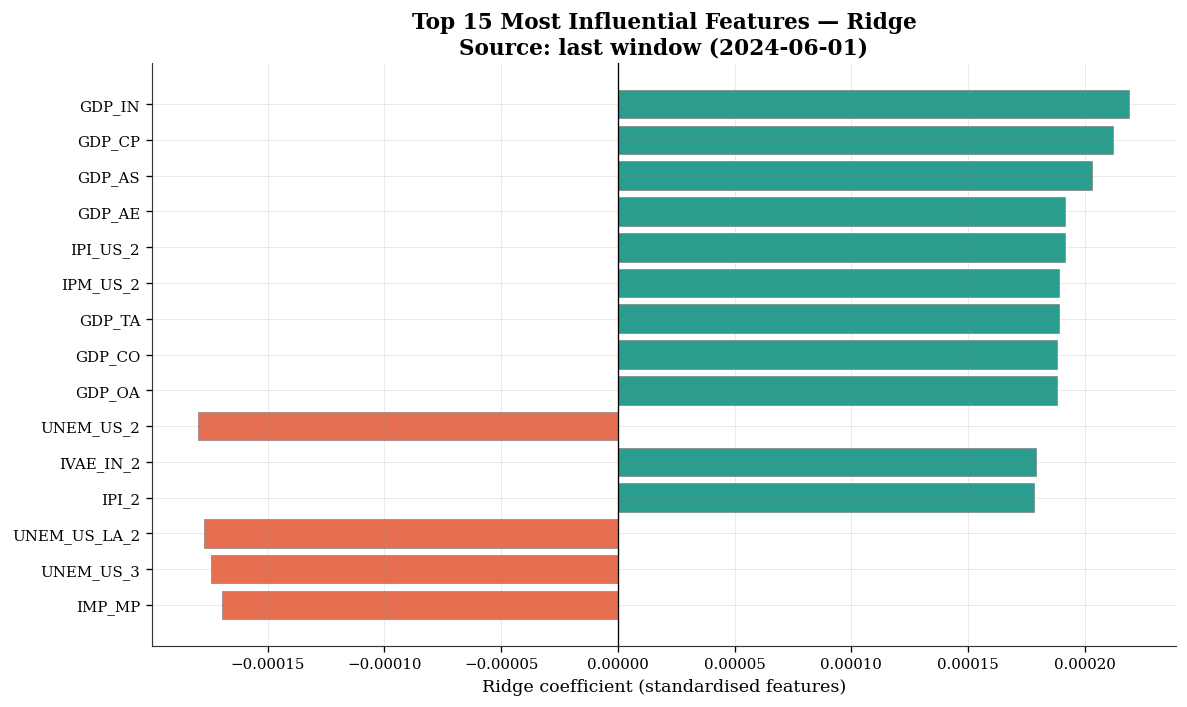

Saved: ridge_plot_features.png


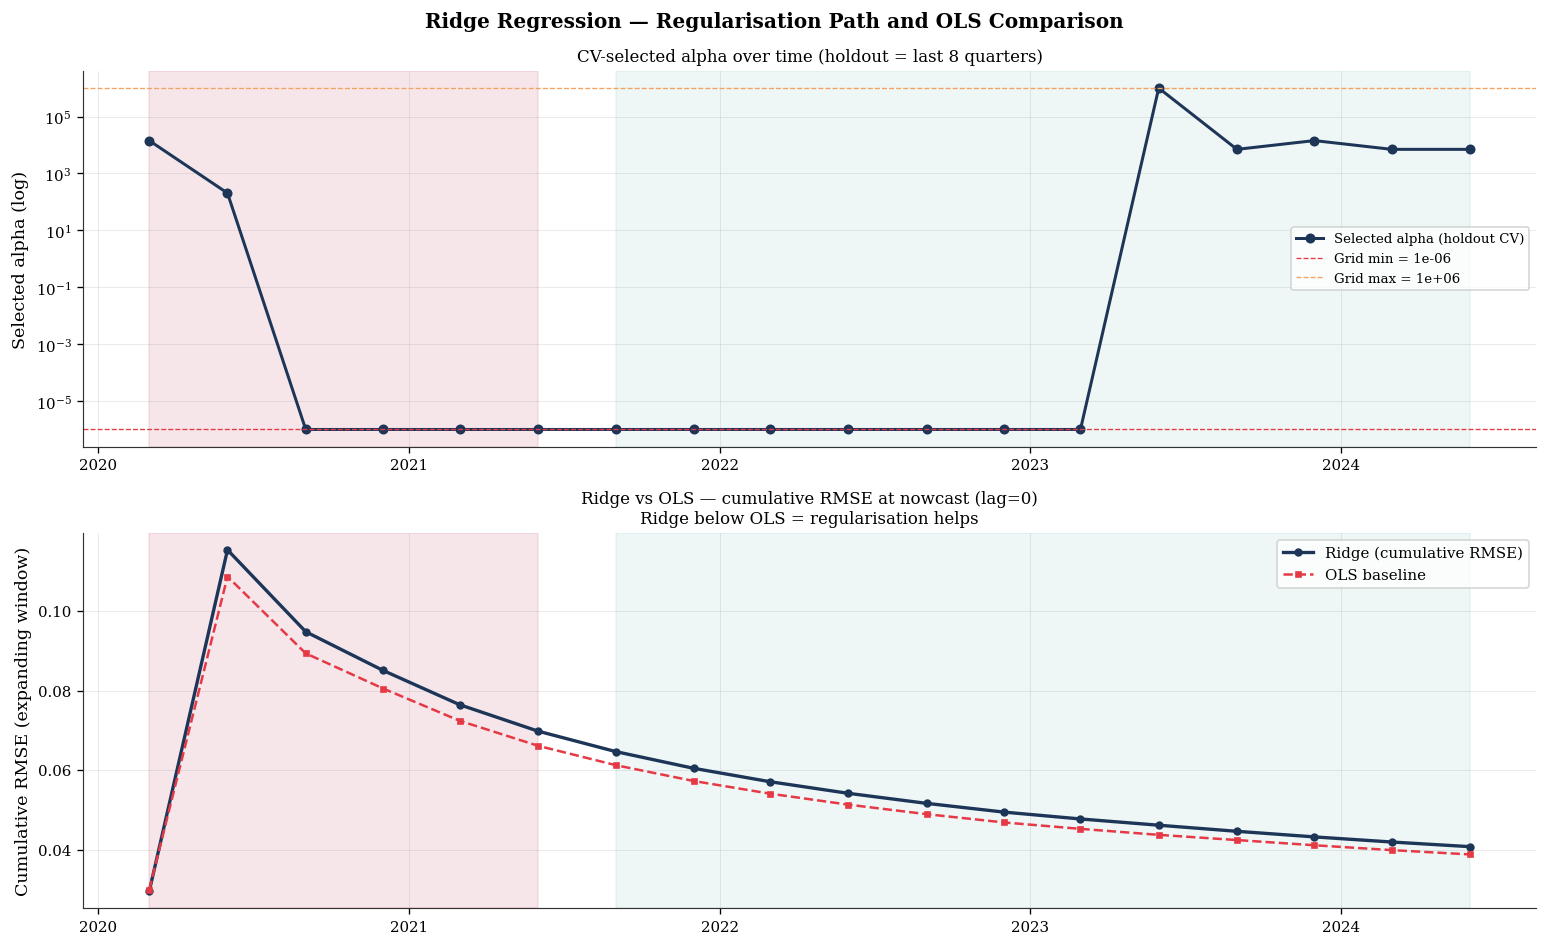

Saved: ridge_plot_alpha.png

RIDGE NOWCASTING COMPLETE
Output : /Users/gabrielaaquino/Desktop/ESA-gdp-nowcasting/Models/results/ridge


In [1]:
# =============================================================================
# Ridge.py
# Ridge Regression nowcasting pipeline for El Salvador GDP.
# Alpha selected via fixed holdout (last 8 quarters of training window).
# OLS baseline included (LinearRegression with SVD/pseudoinverse under p>n)
# so the value of shrinkage is directly visible.
#
# Author : Gabriela Aquino
# =============================================================================
#
# TUNABLE PARAMETERS (safe to modify — see Section 1):
#   N_LAGS_FEATURES     : monthly lags per predictor (baseline = 4)
#   ALPHA_LOG_MIN/MAX   : log-spaced alpha grid
#   N_HOLDOUT_QUARTERS  : size of fixed holdout for alpha selection (default 8)
#
# SHARED CONFIG (do not modify — comes from nowcast_utils.py):
#   LAGS, TRAIN_START, TEST_START, TEST_END,
#   CRISIS_START/END, NORMAL_START/END, etc.
# =============================================================================

import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import StandardScaler

# Selective warning filters.
# We WANT to see sklearn numerical warnings and our own warnings from
# gen_lagged_data (missing metadata). Silence only noisy FutureWarning
# and UserWarning from third parties.
warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# =============================================================================
# 0. PATHS AND SHARED-CONFIG IMPORT
# =============================================================================
BASE_DIR  = Path.home() / "Desktop" / "ESA-gdp-nowcasting"
DATA_DIR  = BASE_DIR / "Data"
MODEL_DIR = BASE_DIR / "Models"
OUT_DIR   = MODEL_DIR / "results" / "ridge"
OUT_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(MODEL_DIR))

from nowcast_utils import (
    LAGS, TARGET_VARIABLE,
    TRAIN_START, TEST_START, TEST_END,
    CRISIS_START, CRISIS_END,
    NORMAL_START, NORMAL_END,
    RANDOM_SEED,
    gen_lagged_data, flatten_data, mean_fill_dataset,
    classify_crisis_periods,
    rmse, mae,
)

PATH_DATA = DATA_DIR / "data_tf.csv"
PATH_META = DATA_DIR / "meta_data_v2.csv"
for p in [PATH_DATA, PATH_META]:
    if not p.exists():
        raise FileNotFoundError(f"\n  File not found: {p}")

# =============================================================================
# 1. TUNABLE PARAMETERS (Ridge-specific)
# =============================================================================
# Number of monthly lags per predictor (same as Lasso for comparability).
# Try: 2 (light), 4 (baseline), 6 (extended)
N_LAGS_FEATURES: int = 4

# Alpha grid: Ridge needs larger alphas than Lasso.
# If grid_min=HIT_MIN appears, lower ALPHA_LOG_MIN.
# If grid_max=HIT_MAX appears, raise ALPHA_LOG_MAX.
ALPHA_LOG_MIN: int      = -6   # 1e-6
ALPHA_LOG_MAX: int      =  6   # 1e6
ALPHA_N_CANDIDATES: int = 40
ALPHA_GRID = np.logspace(ALPHA_LOG_MIN, ALPHA_LOG_MAX, ALPHA_N_CANDIDATES)

# Fixed holdout: last N quarters of training used for alpha selection.
# MUST match lasso_final.py for Ridge/Lasso comparability.
N_HOLDOUT_QUARTERS: int = 8

np.random.seed(RANDOM_SEED)

# =============================================================================
# 2. LOAD DATA
# =============================================================================
print("Loading data...")
data     = pd.read_csv(PATH_DATA, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
metadata = pd.read_csv(PATH_META)

print(f"  Rows       : {data.shape[0]}")
print(f"  Columns    : {data.shape[1]}")
print(f"  Date range : {data['date'].min().date()} to {data['date'].max().date()}")
print(f"  GDP obs    : {data[TARGET_VARIABLE].notna().sum()} quarterly observations")

test_dates = pd.date_range(TEST_START, TEST_END, freq="3MS").strftime("%Y-%m-%d").tolist()

# =============================================================================
# 3. ROLLING-ORIGIN EVALUATION
# =============================================================================
print("\nRunning rolling-origin evaluation...")
print(f"  Train start     : {TRAIN_START}")
print(f"  Test window     : {TEST_START} to {TEST_END}")
print(f"  Vintages        : {LAGS}")
print(f"  Lag depth       : {N_LAGS_FEATURES} monthly lags per predictor")
print(f"  Alpha grid      : {ALPHA_N_CANDIDATES} candidates in [1e{ALPHA_LOG_MIN}, 1e{ALPHA_LOG_MAX}]")
print(f"  Alpha selection : fixed holdout ({N_HOLDOUT_QUARTERS} quarters)")
print(f"  OLS baseline    : LinearRegression (SVD/pseudoinverse under p>n)\n")

pred_dict                    = {lag: [] for lag in LAGS}
pred_dict_ols                = {lag: [] for lag in LAGS}
dates_out                    = []
actuals_out                  = []
lambdas_out                  = []
feature_importance_by_window = []   # list of (date, df) for post-hoc selection
train_cutoff_last            = None

for nowcast_date in test_dates:

    # --- Actual GDP value ----------------------------------------------------
    nowcast_dt  = pd.to_datetime(nowcast_date)
    actual_rows = data.loc[
        (data["date"] == nowcast_dt) & (~pd.isna(data[TARGET_VARIABLE])),
        TARGET_VARIABLE
    ]
    if actual_rows.empty:
        print(f"  [{nowcast_date}] No actual GDP - skipping.")
        for lag in LAGS:
            pred_dict[lag].append(np.nan)
            pred_dict_ols[lag].append(np.nan)
        dates_out.append(nowcast_date)
        actuals_out.append(np.nan)
        lambdas_out.append(np.nan)
        continue

    dates_out.append(nowcast_date)
    actuals_out.append(float(actual_rows.values[0]))

    # --- Training window -----------------------------------------------------
    train_cutoff      = (nowcast_dt - pd.DateOffset(months=3)).strftime("%Y-%m-%d")
    train_cutoff_last = train_cutoff

    train_raw = data.loc[
        (data["date"] >= TRAIN_START) & (data["date"] <= train_cutoff)
    ].copy()

    n_q = train_raw[TARGET_VARIABLE].notna().sum()

    # --- Build feature matrix ------------------------------------------------
    # Mean-fill with training means (standard in nowcasting literature to
    # handle ragged edges). Then flatten to quarterly rows (months 3/6/9/12).
    train_filled = mean_fill_dataset(training=train_raw, test=train_raw)
    train_flat   = flatten_data(train_filled, TARGET_VARIABLE, N_LAGS_FEATURES)
    train_flat   = (
        train_flat
        .loc[train_flat["date"].dt.month.isin([3, 6, 9, 12])]
        .dropna(axis=0, how="any")
        .reset_index(drop=True)
    )

    if len(train_flat) < N_HOLDOUT_QUARTERS + 5:
        print(f"  [{nowcast_date}] Only {len(train_flat)} rows - skipping.")
        for lag in LAGS:
            pred_dict[lag].append(np.nan)
            pred_dict_ols[lag].append(np.nan)
        lambdas_out.append(np.nan)
        continue

    X_train = train_flat.drop(columns=["date", TARGET_VARIABLE])
    y_train = train_flat[TARGET_VARIABLE]

    # --- Alpha selection via fixed holdout -----------------------------------
    # Protocol identical to lasso_final.py — ensures Ridge and Lasso are
    # evaluated under the same tuning conditions.
    #
    # inner-train: all quarters except the last N_HOLDOUT_QUARTERS
    # holdout    : last N_HOLDOUT_QUARTERS of the training window
    # scaler_inner fitted on inner-train only — holdout never influences it.
    X_inner = X_train.iloc[:-N_HOLDOUT_QUARTERS]
    y_inner = y_train.iloc[:-N_HOLDOUT_QUARTERS]
    X_hold  = X_train.iloc[-N_HOLDOUT_QUARTERS:]
    y_hold  = y_train.iloc[-N_HOLDOUT_QUARTERS:]

    scaler_inner = StandardScaler().fit(X_inner)
    X_inner_s    = scaler_inner.transform(X_inner)
    X_hold_s     = scaler_inner.transform(X_hold)

    # Scaler for final model: fit on full training window (all pre-cutoff).
    scaler  = StandardScaler().fit(X_train)
    X_all_s = scaler.transform(X_train)

    # Search alpha grid
    best_alpha, best_rmse = None, np.inf
    for alpha_candidate in ALPHA_GRID:
        ridge_cv = Ridge(alpha=alpha_candidate, fit_intercept=True)
        ridge_cv.fit(X_inner_s, y_inner)
        val_rmse = rmse(y_hold, ridge_cv.predict(X_hold_s))
        if val_rmse < best_rmse:
            best_rmse  = val_rmse
            best_alpha = alpha_candidate

    lambdas_out.append(best_alpha)

    # --- Refit Ridge on full training with best alpha ------------------------
    final_ridge = Ridge(alpha=best_alpha, fit_intercept=True)
    final_ridge.fit(X_all_s, y_train)

    # --- OLS baseline --------------------------------------------------------
    # LinearRegression uses SVD + pseudoinverse under p>n.
    # This IS OLS (the minimum-norm least-squares solution), not a
    # Ridge approximation. Directly comparable to the Ridge model above.
    ols_model = LinearRegression(fit_intercept=True)
    ols_model.fit(X_all_s, y_train)

    # --- Diagnostics print ---------------------------------------------------
    min_warn = "HIT_MIN" if best_alpha <= ALPHA_GRID[1]  else "ok"
    max_warn = "HIT_MAX" if best_alpha >= ALPHA_GRID[-2] else "ok"
    print(f"  [{nowcast_date}]  alpha={best_alpha:.2e}  n_train={n_q}  "
          f"features={X_train.shape[1]}  "
          f"grid_min={min_warn}  grid_max={max_warn}")

    # --- Predict for each vintage -------------------------------------------
    for lag in LAGS:
        vintage_data = gen_lagged_data(metadata, data, nowcast_date, lag)
        vintage_data = mean_fill_dataset(training=train_raw, test=vintage_data)
        vintage_flat = flatten_data(vintage_data, TARGET_VARIABLE, N_LAGS_FEATURES)

        target_row = vintage_flat.loc[vintage_flat["date"] == nowcast_dt]
        if target_row.empty:
            pred_dict[lag].append(np.nan)
            pred_dict_ols[lag].append(np.nan)
            continue

        X_test = (
            target_row
            .drop(columns=["date", TARGET_VARIABLE], errors="ignore")
            .reindex(columns=X_train.columns, fill_value=0.0)
        )
        X_test_s = scaler.transform(X_test)

        pred_dict[lag].append(float(final_ridge.predict(X_test_s)[0]))
        pred_dict_ols[lag].append(float(ols_model.predict(X_test_s)[0]))

    feature_importance_by_window.append((
        nowcast_date,
        pd.DataFrame({
            "feature":     X_train.columns,
            "coefficient": final_ridge.coef_,
        }).assign(abs_coef=lambda df: df["coefficient"].abs())
    ))

# =============================================================================
# 4. PERFORMANCE METRICS
# =============================================================================
# Period labels come from nowcast_utils (single source of truth)
period_labels = classify_crisis_periods(dates_out).tolist()

# --- Full test period --------------------------------------------------------
full_rows = []
for lag in LAGS:
    full_rows.append({
        "Vintage":  lag,
        "RMSE":     round(rmse(actuals_out, pred_dict[lag]),     6),
        "MAE":      round(mae(actuals_out,  pred_dict[lag]),     6),
        "RMSE_OLS": round(rmse(actuals_out, pred_dict_ols[lag]), 6),
        "n":        sum(1 for v in pred_dict[lag] if not np.isnan(v)),
    })
perf_full = pd.DataFrame(full_rows)

# --- Stratified: Crisis / Normal --------------------------------------------
strat_rows = []
for period, label in [
    ("crisis", "Crisis (2020Q1-2021Q2)"),
    ("normal", "Normal (2021Q3-2024Q2)"),
]:
    idx = [i for i, p in enumerate(period_labels) if p == period]
    y   = [actuals_out[i] for i in idx]
    for lag in LAGS:
        yhat     = [pred_dict[lag][i]     for i in idx]
        yhat_ols = [pred_dict_ols[lag][i] for i in idx]
        strat_rows.append({
            "Period":   label,
            "Vintage":  lag,
            "n":        len([v for v in yhat if not np.isnan(v)]),
            "RMSE":     round(rmse(y, yhat),     6),
            "MAE":      round(mae(y,  yhat),     6),
            "RMSE_OLS": round(rmse(y, yhat_ols), 6),
        })
perf_strat = pd.DataFrame(strat_rows)

# --- Print results -----------------------------------------------------------
print("\n" + "=" * 64)
print("FULL TEST PERIOD — Ridge vs OLS")
print("=" * 64)
print(perf_full.to_string(index=False))

print("\n" + "=" * 64)
print("STRATIFIED — Crisis vs Normal")
print("=" * 64)
print(perf_strat.to_string(index=False))

# --- Regularisation benefit --------------------------------------------------
nowcast_ridge = perf_full.loc[perf_full["Vintage"] == 0, "RMSE"].values[0]
nowcast_ols   = perf_full.loc[perf_full["Vintage"] == 0, "RMSE_OLS"].values[0]
benefit       = (nowcast_ols - nowcast_ridge) / nowcast_ols * 100

print(f"\nRegularisation benefit at nowcast (lag=0):")
print(f"  Ridge RMSE : {nowcast_ridge:.6f}")
print(f"  OLS RMSE   : {nowcast_ols:.6f}")
if benefit > 0:
    print(f"  Ridge is {benefit:.1f}% better than OLS")
else:
    print(f"  OLS is {abs(benefit):.1f}% better than Ridge")
print(f"  Benchmark  : compare against ARMA (see arma_benchmark.csv)")

# =============================================================================
# 5. SAVE CSVs
# =============================================================================
pred_table = pd.DataFrame({
    "date":           dates_out,
    "actual":         actuals_out,
    **{f"lag_{'-' if lag < 0 else '+'}{abs(lag)}": pred_dict[lag] for lag in LAGS},
    "period_type":    period_labels,
    "selected_alpha": lambdas_out,
})

pred_table.to_csv(OUT_DIR  / "ridge_predictions.csv",            index=False)
perf_full.to_csv(OUT_DIR   / "ridge_performance_full.csv",       index=False)
perf_strat.to_csv(OUT_DIR  / "ridge_performance_stratified.csv", index=False)

# --- Feature importance: pick a representative window ----------------------
# Prefer last pre-crisis window to avoid COVID-period coefficient instability.
crisis_start_dt = pd.to_datetime(CRISIS_START)
pre_crisis = [
    (d, df) for (d, df) in feature_importance_by_window
    if pd.to_datetime(d) < crisis_start_dt
]

if pre_crisis:
    chosen_date, chosen_df = pre_crisis[-1]
    feature_importance_source = f"last pre-crisis window ({chosen_date})"
elif feature_importance_by_window:
    chosen_date, chosen_df = feature_importance_by_window[-1]
    feature_importance_source = f"last window ({chosen_date})"
else:
    chosen_df = None
    feature_importance_source = "no window available"

if chosen_df is not None:
    (chosen_df
     .sort_values("abs_coef", ascending=False)
     .to_csv(OUT_DIR / "ridge_feature_importance.csv", index=False))
    print(f"\nFeature importance from: {feature_importance_source}")

print(f"\nCSVs saved to: {OUT_DIR}")

# =============================================================================
# 6. PLOTTING STYLE (matches ARMA/Lasso for visual consistency)
# =============================================================================
STYLE = {
    "c_crisis":         "#B6213B",
    "c_normal":         "#2A8F93",
    "c_actual":         "#2E2E2E",
    "zero_line_colour": "#555555",
    "shade_crisis":     0.11,
    "shade_normal":     0.08,
}
plt.rcParams.update({
    "font.family":       "serif",
    "axes.titlesize":    13,
    "axes.labelsize":    10.5,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "axes.grid":         True,
    "grid.alpha":        0.20,
    "grid.color":        "#888888",
    "grid.linewidth":    0.5,
    "axes.edgecolor":    "#333333",
    "axes.linewidth":    0.7,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.dpi":        120,
})

# Vintage styling — 3 vintages only
LAG_COLORS = {-2: "#a8dadc", -1: "#457b9d", 0: "#1d3557"}
LAG_LW     = {-2: 1.2, -1: 1.2, 0: 2.4}
LAG_LS     = {-2: "--", -1: "--", 0: "-"}
LAG_LABELS = {-2: "lag=-2 (forecast)",
              -1: "lag=-1 (early nowcast)",
               0: "lag= 0 (nowcast)"}


def _format_xaxis(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))


def _shade_regimes(ax):
    ax.axvspan(pd.to_datetime(CRISIS_START), pd.to_datetime(CRISIS_END),
               alpha=STYLE["shade_crisis"], color=STYLE["c_crisis"],
               edgecolor="none", zorder=0)
    ax.axvspan(pd.to_datetime(NORMAL_START), pd.to_datetime(NORMAL_END),
               alpha=STYLE["shade_normal"], color=STYLE["c_normal"],
               edgecolor="none", zorder=0)


full_series = (
    data[["date", TARGET_VARIABLE]]
    .dropna(subset=[TARGET_VARIABLE])
    .sort_values("date")
    .reset_index(drop=True)
)

# =============================================================================
# 7. PLOT A — Crisis period (2020Q1–2021Q2)
# =============================================================================
crisis_rows = pred_table[pred_table["period_type"] == "crisis"].copy()
crisis_rows["date"] = pd.to_datetime(crisis_rows["date"])

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(full_series["date"], full_series[TARGET_VARIABLE],
        color="#444444", lw=1.3, marker="o", ms=3, alpha=0.65,
        label="Actual GDP (2005–2024)", zorder=3)
ax.axvspan(pd.to_datetime(CRISIS_START), pd.to_datetime(CRISIS_END),
           alpha=0.13, color=STYLE["c_crisis"], zorder=0,
           label="Crisis window (2020Q1–2021Q2)")
ax.axhline(0, color=STYLE["zero_line_colour"], lw=0.8, alpha=0.4, zorder=1)

for lag in LAGS:
    col = f"lag_{'-' if lag < 0 else '+'}{abs(lag)}"
    ax.plot(crisis_rows["date"], crisis_rows[col],
            color=LAG_COLORS[lag], lw=LAG_LW[lag], ls=LAG_LS[lag],
            marker="o", ms=4.5, label=LAG_LABELS[lag], zorder=5)

ax.set_xlabel("Date")
ax.set_ylabel("GDP growth rate (QoQ)")
ax.set_title("Ridge Regression — Crisis Period (2020Q1–2021Q2)\n"
             "Nowcasting Vintages | El Salvador",
             fontweight="bold")
ax.legend(fontsize=8, ncol=3, loc="lower left")
_format_xaxis(ax)
plt.tight_layout()
fig.savefig(OUT_DIR / "ridge_plot_crisis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ridge_plot_crisis.png")

# =============================================================================
# 8. PLOT B — Normal period (2021Q3–2024Q2)
# =============================================================================
normal_rows = pred_table[pred_table["period_type"] == "normal"].copy()
normal_rows["date"] = pd.to_datetime(normal_rows["date"])

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(full_series["date"], full_series[TARGET_VARIABLE],
        color="#444444", lw=1.3, marker="o", ms=3, alpha=0.65,
        label="Actual GDP (2005–2024)", zorder=3)
ax.axvspan(pd.to_datetime(NORMAL_START), pd.to_datetime(NORMAL_END),
           alpha=0.12, color=STYLE["c_normal"], zorder=0,
           label="Normal window (2021Q3–2024Q2)")
ax.axvspan(pd.to_datetime(CRISIS_START), pd.to_datetime(CRISIS_END),
           alpha=0.07, color=STYLE["c_crisis"], zorder=0,
           label="Crisis period (reference)")
ax.axhline(0, color=STYLE["zero_line_colour"], lw=0.8, alpha=0.4, zorder=1)

for lag in LAGS:
    col = f"lag_{'-' if lag < 0 else '+'}{abs(lag)}"
    ax.plot(normal_rows["date"], normal_rows[col],
            color=LAG_COLORS[lag], lw=LAG_LW[lag], ls=LAG_LS[lag],
            marker="o", ms=4.5, label=LAG_LABELS[lag], zorder=5)

ax.set_xlabel("Date")
ax.set_ylabel("GDP growth rate (QoQ)")
ax.set_title("Ridge Regression — Normal Period (2021Q3–2024Q2)\n"
             "Nowcasting Vintages | El Salvador",
             fontweight="bold")
ax.legend(fontsize=8, ncol=3, loc="lower left")
_format_xaxis(ax)
plt.tight_layout()
fig.savefig(OUT_DIR / "ridge_plot_normal.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ridge_plot_normal.png")

# =============================================================================
# 9. PLOT C — RMSE heatmap
# =============================================================================
pivot = perf_strat.pivot(index="Period", columns="Vintage", values="RMSE")
fig, ax = plt.subplots(figsize=(9, 3))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlOrRd",
            linewidths=0.6, ax=ax, cbar_kws={"label": "RMSE", "shrink": 0.8})
ax.set_title("Ridge Regression — RMSE by Period and Vintage",
             fontweight="bold", pad=10)
ax.set_xlabel("Vintage (months relative to quarter-end)")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(OUT_DIR / "ridge_plot_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ridge_plot_heatmap.png")

# =============================================================================
# 10. PLOT D — Feature importance
# =============================================================================
if chosen_df is not None:
    top_n     = 15
    top_feats = (chosen_df
                 .sort_values("abs_coef", ascending=False)
                 .head(top_n))
    bar_cols  = ["#2a9d8f" if c >= 0 else "#e76f51"
                 for c in top_feats["coefficient"]]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_feats["feature"][::-1],
            top_feats["coefficient"][::-1],
            color=bar_cols[::-1], edgecolor="gray", linewidth=0.4)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Ridge coefficient (standardised features)")
    ax.set_title(f"Top {top_n} Most Influential Features — Ridge\n"
                 f"Source: {feature_importance_source}",
                 fontweight="bold")
    plt.tight_layout()
    fig.savefig(OUT_DIR / "ridge_plot_features.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: ridge_plot_features.png")

# =============================================================================
# 11. PLOT E — Alpha path + Ridge vs OLS cumulative RMSE
# =============================================================================
valid_alpha = [(d, a) for d, a in zip(dates_out, lambdas_out)
               if a is not None and not np.isnan(a)]

if valid_alpha:
    alpha_dates  = pd.to_datetime([x[0] for x in valid_alpha])
    alpha_values = [x[1] for x in valid_alpha]

    fig, axes = plt.subplots(2, 1, figsize=(13, 8))
    fig.suptitle("Ridge Regression — Regularisation Path and OLS Comparison",
                 fontweight="bold")

    # Panel A: alpha over time
    ax = axes[0]
    _shade_regimes(ax)
    ax.plot(alpha_dates, alpha_values, color="#1d3557", lw=1.8,
            marker="o", ms=5, label="Selected alpha (holdout CV)")
    ax.axhline(ALPHA_GRID[0],  color="#e63946", lw=0.8, ls="--",
               label=f"Grid min = {ALPHA_GRID[0]:.0e}")
    ax.axhline(ALPHA_GRID[-1], color="#f4a261", lw=0.8, ls="--",
               label=f"Grid max = {ALPHA_GRID[-1]:.0e}")
    ax.set_yscale("log")
    ax.set_ylabel("Selected alpha (log)")
    ax.set_title(f"CV-selected alpha over time (holdout = last {N_HOLDOUT_QUARTERS} quarters)",
                 fontsize=10)
    ax.legend(fontsize=8)
    _format_xaxis(ax)

    # Panel B: cumulative RMSE Ridge vs OLS at nowcast (lag=0)
    ridge_preds = pred_dict[0]
    ols_preds   = pred_dict_ols[0]
    cum_rmse_ridge = [rmse(actuals_out[:i], ridge_preds[:i])
                      for i in range(1, len(actuals_out) + 1)]
    cum_rmse_ols   = [rmse(actuals_out[:i], ols_preds[:i])
                      for i in range(1, len(actuals_out) + 1)]

    dates_dt = pd.to_datetime(dates_out)
    ax = axes[1]
    _shade_regimes(ax)
    ax.plot(dates_dt, cum_rmse_ridge, color="#1d3557", lw=2,
            marker="o", ms=4, label="Ridge (cumulative RMSE)")
    ax.plot(dates_dt, cum_rmse_ols, color="#e63946", lw=1.5,
            ls="--", marker="s", ms=3, label="OLS baseline")
    ax.set_ylabel("Cumulative RMSE (expanding window)")
    ax.set_title("Ridge vs OLS — cumulative RMSE at nowcast (lag=0)\n"
                 "Ridge below OLS = regularisation helps",
                 fontsize=10)
    ax.legend(fontsize=9)
    _format_xaxis(ax)

    plt.tight_layout()
    fig.savefig(OUT_DIR / "ridge_plot_alpha.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: ridge_plot_alpha.png")

# =============================================================================
# DONE
# =============================================================================
print("\n" + "=" * 64)
print("RIDGE NOWCASTING COMPLETE")
print("=" * 64)
print(f"Output : {OUT_DIR}")